In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import optuna
from scipy.stats import shapiro, pearsonr

In [4]:
train = pd.read_excel('../../dataset/train set.xlsx')
train.columns

Index(['Reference', 'Sample', 'Soil source', 'ES', 'PFAS', 'PFAS class', 'pH',
       'SOC', 'CEC', 'Sand', 'Silt', 'Clay', 'Species', 'Plant class',
       'Tissue', 'Soil residual concentration', 'ED', 'lnBCF', 'Family',
       'Genus', 'Order', 'monocot', 'woody', 'herb', 'crop', 'vegetable',
       'legume', 'grass', 'perennial', 'edible', 'group', 'MaxAbsEStateIndex',
       'MinAbsEStateIndex', 'qed', 'SPS', 'MaxPartialCharge',
       'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
       'BCUT2D_MWLOW', 'BCUT2D_MRLOW', 'HallKierAlpha', 'Ipc', 'Kappa3',
       'PEOE_VSA13', 'PEOE_VSA3', 'PEOE_VSA8', 'SMR_VSA4', 'SlogP_VSA12',
       'EState_VSA8', 'EState_VSA9', 'VSA_EState7', 'FractionCSP3',
       'NHOHCount'],
      dtype='object')

In [5]:
train['logIpc'] = np.log10(train['Ipc'])
train['logSRC'] = np.log10(train['Soil residual concentration'])
train['logED'] = np.log10(train['ED'])

In [6]:
X_train = train.drop(columns=[
    "lnBCF","Reference",'Sample','Soil source','ES','PFAS','PFAS class','Species','Plant class','group','Ipc','Soil residual concentration','ED'
])
y_train = train["lnBCF"]
cat_cols = [
    'Tissue',
    'Family','Genus','Order','monocot','woody','herb','crop','vegetable','legume','grass','perennial','edible'
]
cat_cols = [c for c in cat_cols if c in train.columns] 
groups = train["group"]

In [7]:
# one-hot for sklearn models
X_train_enc = pd.get_dummies(X_train, columns=cat_cols)

X_train.columns = X_train.columns.astype(str)
X_train_enc.columns = X_train_enc.columns.astype(str)

cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

In [8]:
# CV split
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(X_train, y_train, groups))

In [9]:
#Metrics
def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [8]:
#Search spaces
# ---------- CatBoost ----------
cb_param = {
    "depth": [4,6,8],
    "learning_rate": [0.01,0.03,0.05],
    "l2_leaf_reg": [1,3,5,7],
    "iterations": [500,800,1000]
}

# ---------- Random Forest ----------
rf_param = {
    "n_estimators": [300,500,800],
    "max_depth": [None,10,20],
    "min_samples_leaf": [1,2,5],
    "max_features": ["sqrt","log2"]
}

# ---------- MLP ----------
mlp_param = {
    "mlp__hidden_layer_sizes": [(64,), (128,64), (128,64,32)],
    "mlp__alpha": [0.0001,0.001,0.01],
    "mlp__learning_rate_init": [0.001,0.0005]
}

In [27]:
all_results = []
best_params = {}
# ==========================================================
# Model Loop
# ==========================================================
for model_name in ["RandomForest","Ridge","MLP","CatBoost"]:

    print("\n=================================================")
    print("Model:", model_name)
    print("=================================================")

    fold_scores = []

    # ------------------------------------------------------
    # Fold Loop
    # ------------------------------------------------------
    for fold, (tr_idx, val_idx) in enumerate(splits,1):

        print(f"\nFold {fold}")

        # raw
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        # encoded
        X_tr_enc = X_train_enc.iloc[tr_idx]
        X_val_enc = X_train_enc.iloc[val_idx]

        # ==================================================
        # CatBoost
        # ==================================================
        if model_name == "CatBoost":

            base_model = CatBoostRegressor(
                loss_function='RMSE',
                random_seed=42,
                verbose=0
            )

            search = RandomizedSearchCV(
                estimator=base_model,
                param_distributions=cb_param,
                n_iter=20,
                scoring='r2',
                cv=3,
                random_state=42,
                n_jobs=-1
            )

            search.fit(X_tr, y_tr, cat_features=cat_idx)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_val)

        # ==================================================
        # Random Forest
        # ==================================================
        elif model_name == "RandomForest":

            base_model = RandomForestRegressor(random_state=42)

            search = RandomizedSearchCV(
                estimator=base_model,
                param_distributions=rf_param,
                n_iter=20,
                scoring='r2',
                cv=3,
                random_state=42,
                n_jobs=-1
            )

            search.fit(X_tr_enc, y_tr)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_val_enc)

        # ==================================================
        # Ridge
        # ==================================================
        elif model_name == "Ridge":

            best_model = Pipeline([
                ("scaler", StandardScaler()),
                ("ridge", RidgeCV(alphas=np.logspace(0,5,50)))
            ])

            best_model.fit(X_tr_enc, y_tr)
            y_pred = best_model.predict(X_val_enc)

        # ==================================================
        # MLP
        # ==================================================
        elif model_name == "MLP":

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("mlp", MLPRegressor(
                    max_iter=1500,
                    early_stopping=True,
                    random_state=42
                ))
            ])

            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=mlp_param,
                n_iter=15,
                scoring='r2',
                cv=3,
                random_state=42,
                n_jobs=-1
            )

            search.fit(X_tr_enc, y_tr)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_val_enc)

        # --------------------------------------------------
        # Save best params
        # --------------------------------------------------
        if model_name != "Ridge":
            best_params[f"{model_name}_fold{fold}"] = search.best_params_
            print("Best Params:", search.best_params_)

        # --------------------------------------------------
        # Metrics
        # --------------------------------------------------
        m = evaluate(y_val, y_pred)

        print(
            f"R2={m['R2']:.3f} | "
            f"RMSE={m['RMSE']:.3f} | "
            f"MAE={m['MAE']:.3f}"
        )

        fold_scores.append(m)

    # ------------------------------------------------------
    # Summary
    # ------------------------------------------------------
    r2s   = [x["R2"] for x in fold_scores]
    rmses = [x["RMSE"] for x in fold_scores]
    maes  = [x["MAE"] for x in fold_scores]

    result = {
        "Model": model_name,
        "R2_mean": np.mean(r2s),
        "R2_std": np.std(r2s),
        "RMSE_mean": np.mean(rmses),
        "RMSE_std": np.std(rmses),
        "MAE_mean": np.mean(maes),
        "MAE_std": np.std(maes)
    }

    all_results.append(result)


Model: RandomForest

Fold 1
Best Params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
R2=0.435 | RMSE=1.525 | MAE=1.015

Fold 2
Best Params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
R2=0.815 | RMSE=1.482 | MAE=1.137

Fold 3
Best Params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
R2=0.788 | RMSE=1.319 | MAE=0.960

Fold 4
Best Params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
R2=0.795 | RMSE=1.531 | MAE=1.156

Fold 5
Best Params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
R2=0.871 | RMSE=1.077 | MAE=0.807

Model: Ridge

Fold 1
R2=0.388 | RMSE=1.588 | MAE=1.227

Fold 2
R2=0.692 | RMSE=1.914 | MAE=1.415

Fold 3
R2=0.653 | RMSE=1.687 | MAE=1.278

Fold 4
R2=0.572 | RMSE=2.214 | MAE=1.759

Fold 5
R2=-0.204 | RMSE=3.289 | MAE=2.002

Model: MLP

Fold 1
Best Params: {'mlp__learning_

c:\Users\23708\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\23708\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\23708\AppData\Local\Programs\Python\Python310\lib\site-packages\catboost\core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseli

Best Params: {'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 6}
R2=0.522 | RMSE=1.403 | MAE=1.011

Fold 2
Best Params: {'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 1000, 'depth': 8}
R2=0.837 | RMSE=1.392 | MAE=1.066

Fold 3
Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 8}
R2=0.871 | RMSE=1.030 | MAE=0.726

Fold 4
Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 8}
R2=0.848 | RMSE=1.319 | MAE=0.990

Fold 5
Best Params: {'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 6}
R2=0.846 | RMSE=1.176 | MAE=0.894


In [28]:
# Final Table
result_df = pd.DataFrame(all_results)
result_df = result_df.sort_values("R2_mean", ascending=False)

print("\n================ Final Results ================\n")
print(result_df)


================ Final Results ================

          Model   R2_mean    R2_std  RMSE_mean  RMSE_std  MAE_mean   MAE_std
3      CatBoost  0.784601  0.131919   1.264182  0.142331  0.937440  0.119518
0  RandomForest  0.740886  0.155466   1.386679  0.172928  1.014944  0.127075
2           MLP  0.549228  0.559529   1.663026  1.041374  1.081748  0.415362
1         Ridge  0.419952  0.329231   2.138139  0.614191  1.536015  0.297803


          Model   R2_mean    R2_std  RMSE_mean  RMSE_std  MAE_mean   MAE_std
3      CatBoost  0.784601  0.131919   1.264182  0.142331  0.937440  0.119518
0  RandomForest  0.740886  0.155466   1.386679  0.172928  1.014944  0.127075
2           MLP  0.549228  0.559529   1.663026  1.041374  1.081748  0.415362
1         Ridge  0.419952  0.329231   2.138139  0.614191  1.536015  0.297803

In [8]:
# ======================================================
# Optuna objective
# ======================================================
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }

    scores = []

    for train_idx, val_idx in splits:

        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_tr, y_tr,
            cat_features=cat_idx,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0
        )

        pred = model.predict(X_val)
        scores.append(r2_score(y_val, pred))

    return np.mean(scores)

In [10]:
# ======================================================
# Run optimization
# ======================================================
from optuna.pruners import MedianPruner
study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner()
)
study.optimize(objective, n_trials=75)

best_params = study.best_params
print("Best params:", best_params)

[I 2026-04-27 10:17:35,587] A new study created in memory with name: no-name-7572a026-4f60-4cad-b5e9-f2c3a45a3d63
[I 2026-04-27 10:19:07,100] Trial 0 finished with value: 0.8029661455778868 and parameters: {'iterations': 1846, 'depth': 6, 'learning_rate': 0.08653424645812881, 'l2_leaf_reg': 8.611448227133984, 'bagging_temperature': 0.5356445982820505, 'random_strength': 0.3603577354533436, 'subsample': 0.8418613036985126, 'colsample_bylevel': 0.7581297557980988}. Best is trial 0 with value: 0.8029661455778868.
[I 2026-04-27 10:20:47,006] Trial 1 finished with value: 0.8170108148169545 and parameters: {'iterations': 1889, 'depth': 6, 'learning_rate': 0.0689471613034583, 'l2_leaf_reg': 9.562127661313665, 'bagging_temperature': 0.08380396615561858, 'random_strength': 1.923424315667907, 'subsample': 0.6881129503328637, 'colsample_bylevel': 0.6349876502763842}. Best is trial 1 with value: 0.8170108148169545.
[I 2026-04-27 10:25:17,157] Trial 2 finished with value: 0.806836510445844 and para

Best params: {'iterations': 1803, 'depth': 7, 'learning_rate': 0.03823231749308767, 'l2_leaf_reg': 7.85887570845998, 'bagging_temperature': 0.8606437364021795, 'random_strength': 8.94247879276211, 'subsample': 0.8029919474739348, 'colsample_bylevel': 0.7100100060503998}


In [10]:
best_params= {'iterations': 1803, 'depth': 7, 'learning_rate': 0.03823231749308767, 'l2_leaf_reg': 7.85887570845998, 'bagging_temperature': 0.8606437364021795, 'random_strength': 8.94247879276211, 'subsample': 0.8029919474739348, 'colsample_bylevel': 0.7100100060503998}

In [11]:
# ======================================================
# OOF prediction
# ======================================================
oof_pred = np.zeros(len(y_train))
tissue_all = train["Tissue"].reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(splits, 1):

    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    X_val = X_train.iloc[val_idx]

    model = CatBoostRegressor(
        **best_params,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_tr, y_tr,
        cat_features=cat_idx,
        eval_set=(X_val, y_train.iloc[val_idx]),
        early_stopping_rounds=50,
        verbose=0
    )

    oof_pred[val_idx] = model.predict(X_val)

In [12]:
#训练一个全数据最终模型并保存
final_model = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

final_model.fit(
    X_train,
    y_train,
    cat_features=cat_idx
)
final_model.save_model("../Model/catboost_final.cbm")
import json

with open("../Model/features.json", "w") as f:
    json.dump(list(X_train.columns), f)

In [12]:
# ======================================================
# Metrics
# ======================================================
y_true_all = y_train.values
y_pred_all = oof_pred

mean_r2 = r2_score(y_true_all, y_pred_all)
mean_rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mean_mae = mean_absolute_error(y_true_all, y_pred_all)

print("R2:", mean_r2)
print("RMSE:", mean_rmse)
print("MAE:", mean_mae)

R2: 0.8613358411546266
RMSE: 1.1290368102997743
MAE: 0.835584808346401


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


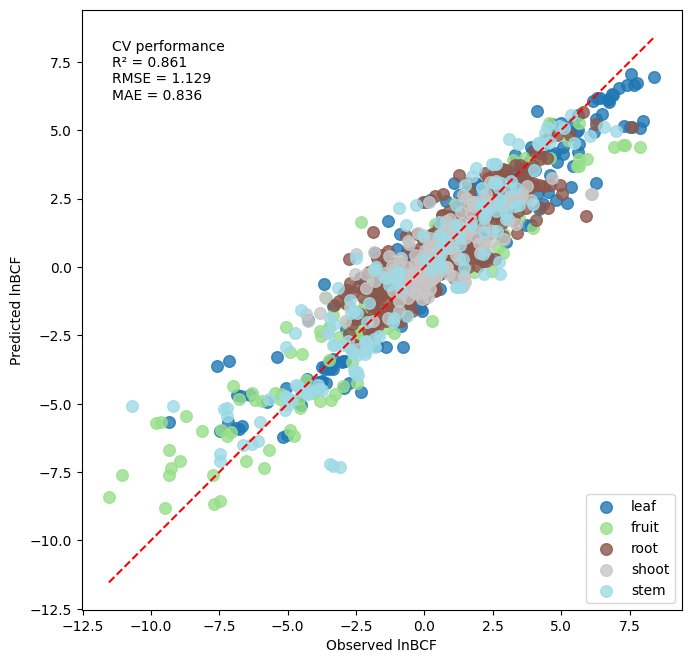

In [13]:
import matplotlib.cm as cm
tissue_all = train["Tissue"].reset_index(drop=True)
# ======================================================
# Plot dataframe
# ======================================================
df_plot = pd.DataFrame({
    "y_true": y_true_all,
    "y_pred": y_pred_all,
    "Tissue": tissue_all
})

# ======================================================
# Scatter plot
# ======================================================
plt.figure(figsize=(7,7))

tissues = df_plot["Tissue"].unique()
#colors = cm.Set3(np.linspace(0, 1, len(tissues)))
colors = cm.tab20(np.linspace(0, 1, len(tissues)))
#colors = cm.Dark2(np.linspace(0, 1, len(tissues)))
#colors = cm.Accent(np.linspace(0, 1, len(tissues)))
color_dict = dict(zip(tissues, colors))


for tissue in tissues:

    sub = df_plot[df_plot["Tissue"] == tissue]

    plt.scatter(
        sub["y_true"],
        sub["y_pred"],
        color=color_dict[tissue],
        alpha=0.8,
        s=70,
        label=tissue
    )

# diagonal line
min_val = min(df_plot["y_true"].min(), df_plot["y_pred"].min())
max_val = max(df_plot["y_true"].max(), df_plot["y_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--")

# text
plt.text(
    0.05, 0.95,
    f"CV performance\nR² = {mean_r2:.3f}\nRMSE = {mean_rmse:.3f}\nMAE = {mean_mae:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Observed lnBCF")
plt.ylabel("Predicted lnBCF")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("../output/eps/CV_performance_by_Tissue.eps")
plt.show()

In [15]:
test = pd.read_excel('../../dataset/test set.xlsx')
test['logIpc'] = np.log10(test['Ipc'])
test['logSRC'] = np.log10(test['Soil residual concentration'])
test['logED'] = np.log10(test['ED'])

In [16]:
test['logIpc'] = np.log10(test['Ipc'])
test.drop(columns=['Reference', 'Sample','Soil source','ES','PFAS','PFAS class','Species','Plant class','group','Ipc',
                   'ED','Soil residual concentration'], inplace=True)
x_test = test.drop(columns=['lnBCF'], errors='ignore').copy()
y_test = test['lnBCF'].copy()
cat_cols = [c for c in cat_cols if c in x_test.columns] 

In [ ]:
y_test_pred = model.predict(x_test)
# mean_r2 = r2_score(y_test, y_test_pred)
# mean_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
# print(mean_r2, mean_rmse)

0.8172071929192481 1.184630480143814


In [18]:
train_res = y_train - oof_pred
test_res  = y_test - y_test_pred
# 转为 numpy array，避免 pandas index 影响
train_res = np.asarray(train_res)
test_res  = np.asarray(test_res)

oof_pred = np.asarray(oof_pred)
y_test_pred = np.asarray(y_test_pred)

# =========================
# Residual statistics
# =========================

# 1. Mean and SD
train_mean = np.mean(train_res)
train_sd   = np.std(train_res, ddof=1)

test_mean = np.mean(test_res)
test_sd   = np.std(test_res, ddof=1)

# 2. Shapiro-Wilk normality test
# Shapiro-Wilk 对超大样本可能有警告，因此这里取最多5000个样本
rng = np.random.default_rng(42)

train_shapiro_res = (
    rng.choice(train_res, size=5000, replace=False)
    if len(train_res) > 5000 else train_res
)

test_shapiro_res = (
    rng.choice(test_res, size=5000, replace=False)
    if len(test_res) > 5000 else test_res
)

train_W, train_p = shapiro(train_shapiro_res)
test_W, test_p = shapiro(test_shapiro_res)

# 3. Pearson correlation between predicted values and residuals
train_r, train_rp = pearsonr(oof_pred, train_res)
test_r, test_rp = pearsonr(y_test_pred, test_res)

# =========================
# Print statistics
# =========================

print("===== Train Residuals =====")
print(f"Mean = {train_mean:.4f}")
print(f"SD   = {train_sd:.4f}")
print(f"Shapiro-Wilk W = {train_W:.4f}, P = {train_p:.4g}")
print(f"Residual-Predicted Pearson r = {train_r:.4f}, P = {train_rp:.4g}")

print("\n===== Test Residuals =====")
print(f"Mean = {test_mean:.4f}")
print(f"SD   = {test_sd:.4f}")
print(f"Shapiro-Wilk W = {test_W:.4f}, P = {test_p:.4g}")
print(f"Residual-Predicted Pearson r = {test_r:.4f}, P = {test_rp:.4g}")

===== Train Residuals =====
Mean = 0.0069
SD   = 1.1295
Shapiro-Wilk W = 0.9780, P = 4.704e-12
Residual-Predicted Pearson r = 0.1492, P = 4.777e-07

===== Test Residuals =====
Mean = 0.3197
SD   = 1.1429
Shapiro-Wilk W = 0.9928, P = 0.2388
Residual-Predicted Pearson r = 0.4504, P = 2.436e-14


In [19]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# =========================
# Breusch-Pagan test
# =========================

# Train
X_train_bp = sm.add_constant(oof_pred)
bp_train = het_breuschpagan(train_res, X_train_bp)

# Test
X_test_bp = sm.add_constant(y_test_pred)
bp_test = het_breuschpagan(test_res, X_test_bp)

# Results
bp_names = [
    "LM Statistic",
    "LM-Test P-value",
    "F Statistic",
    "F-Test P-value"
]

print("===== Breusch-Pagan Test: Train =====")
for name, value in zip(bp_names, bp_train):
    print(f"{name}: {value:.6f}")

print("\n===== Breusch-Pagan Test: Test =====")
for name, value in zip(bp_names, bp_test):
    print(f"{name}: {value:.6f}")

===== Breusch-Pagan Test: Train =====
LM Statistic: 21.053694
LM-Test P-value: 0.000004
F Statistic: 21.415761
F-Test P-value: 0.000004

===== Breusch-Pagan Test: Test =====
LM Statistic: 0.659275
LM-Test P-value: 0.416816
F Statistic: 0.655853
F-Test P-value: 0.418777


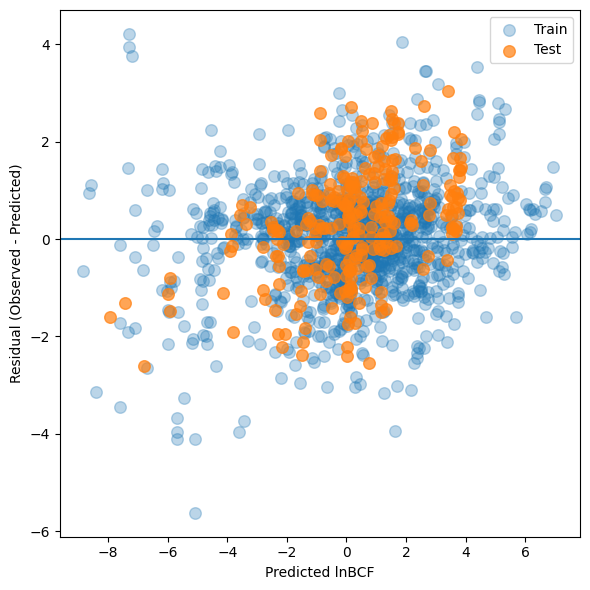

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(oof_pred, train_res, alpha=0.3, label="Train",s=70)
plt.scatter(y_test_pred, test_res, alpha=0.7, label="Test",s=70)

plt.axhline(y=0)

plt.xlabel("Predicted lnBCF")
plt.ylabel("Residual (Observed - Predicted)")
plt.legend()

#plt.title("Residual Plot (Train vs Test)")

plt.tight_layout()
#plt.savefig("../output/eps/cancha.eps")
plt.show()

In [19]:
X_train.describe()

,pH,SOC,CEC,Sand,Silt,Clay,monocot,woody,herb,crop,...,SMR_VSA4,SlogP_VSA12,EState_VSA8,EState_VSA9,VSA_EState7,FractionCSP3,NHOHCount,logIpc,logSRC,logED
count,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.0,1129.0,1129.0,...,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000
mean,6.422524,1.357695,19.508237,63.542870,26.239947,10.217183,0.246236,0.0,1.0,1.0,...,0.018207,0.076218,0.106358,4.886950,-7.849449,0.889519,0.989371,4.456314,1.717993,1.968310
std,1.009802,0.850322,16.941002,15.285629,9.458866,7.755626,0.431008,0.0,0.0,0.0,...,0.305479,0.768727,0.938392,0.696385,1.729886,0.082140,0.132731,1.501359,1.149334,0.222236
min,5.500000,0.210000,3.600000,25.000000,4.100000,4.100000,0.000000,0.0,1.0,1.0,...,0.000000,0.000000,0.000000,0.000000,-24.135725,0.666667,0.000000,1.986557,-1.397940,1.447158
25%,5.670000,0.930000,16.000000,50.000000,24.000000,5.000000,0.000000,0.0,1.0,1.0,...,0.000000,0.000000,0.000000,4.893412,-7.950308,0.833333,1.000000,3.083578,0.954243,1.826075
50%,5.670000,0.930000,16.000000,71.000000,24.000000,5.000000,0.000000,0.0,1.0,1.0,...,0.000000,0.000000,0.000000,5.106527,-7.693838,0.888889,1.000000,4.174192,1.687161,2.021189
75%,7.500000,1.467517,19.000000,71.000000,33.000000,17.000000,0.000000,0.0,1.0,1.0,...,0.000000,0.000000,0.000000,5.106527,-7.134306,1.000000,1.000000,5.246889,2.495128,2.082785
max,8.750000,6.340000,96.000000,87.900000,46.000000,39.400000,1.000000,0.0,1.0,1.0,...,5.138974,7.822697,9.047494,5.106527,-6.602292,1.000000,2.000000,11.722709,3.950316,2.380211
